# HoeffdingTree Missing-Value Policy Experiments

This notebook compares `HoeffdingTree(missing_value_policy=...)` on several CapyMOA classification datasets.

The experiment is prequential: predict first, update a `ClassificationEvaluator`, then train on the same instance. Missing values are injected only into the prediction copy, while training still receives the original complete instance. This isolates how each prediction-time missing-value policy behaves:

- `default`: use MOA's default routing behavior
- `random`: follow one randomly chosen child
- `all`: follow all reachable children and combine their votes



## Imports

In [ ]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from capymoa.classifier import HoeffdingTree
from capymoa.datasets import Covtype, Electricity, Hyper100k, RBFm_100k, RTG_2abrupt
from capymoa.evaluation import ClassificationEvaluator
from capymoa.instance import Instance

In [ ]:
DATASETS = {
    "Electricity": Electricity,
    "Covtype": Covtype,
    "Hyper100k": Hyper100k,
    "RBFm_100k": RBFm_100k,
    "RTG_2abrupt": RTG_2abrupt,
}

POLICIES = ["default", "random", "all"]
MISSING_RATES = [0.0, 0.3, 0.5, 0.7, 0.9]
SEED = 49

## Helper Functions

In [ ]:
def inject_missing_values(schema, instance, rng, missing_rate):
    """Return an unlabeled prediction instance with randomly missing features."""
    x = np.asarray(instance.x, dtype=float).copy()
    mask = rng.random(x.shape[0]) < missing_rate

    if missing_rate > 0 and not mask.any():
        mask[rng.integers(x.shape[0])] = True

    x[mask] = np.nan
    prediction_instance = Instance.from_array(schema, x)
    java_data = prediction_instance.java_instance.getData()

    for index in np.flatnonzero(mask):
        java_data.setMissing(int(index))

    return prediction_instance, int(mask.sum())


def evaluate_dataset(dataset_name, dataset_cls, policy, missing_rate, seed=SEED):
    stream = dataset_cls()
    schema = stream.get_schema()
    learner = HoeffdingTree(
        schema=schema,
        random_seed=seed,
        missing_value_policy=policy,
    )
    evaluator = ClassificationEvaluator(schema=schema)
    rng = np.random.default_rng(seed)

    instances = 0
    abstained = 0
    missing_values = 0
    start = perf_counter()

    for instance in stream:
        prediction_instance, n_missing = inject_missing_values(
            schema=schema,
            instance=instance,
            rng=rng,
            missing_rate=missing_rate,
        )
        missing_values += n_missing

        prediction = learner.predict(prediction_instance)
        abstained += int(prediction is None)
        evaluator.update(instance.y_index, prediction)
        learner.train(instance)
        instances += 1

    elapsed = perf_counter() - start
    return {
        "dataset": dataset_name,
        "policy": policy,
        "missing_rate": missing_rate,
        "instances": instances,
        "accuracy": evaluator.accuracy(),
        "abstained": abstained,
        "missing_values": missing_values,
        "seconds": elapsed,
        "instances_per_second": instances / elapsed if elapsed else np.nan,
    }

## Run The Sweep

In [4]:
rows = []

for dataset_name, dataset_cls in DATASETS.items():
    for missing_rate in MISSING_RATES:
        for policy in POLICIES:
            print(f"{dataset_name:15s} missing_rate={missing_rate:.1f} policy={policy}")
            rows.append(
                evaluate_dataset(
                    dataset_name=dataset_name,
                    dataset_cls=dataset_cls,
                    policy=policy,
                    missing_rate=missing_rate,
                )
            )

results = pd.DataFrame(rows)

Electricity     missing_rate=0.0 policy=default
Electricity     missing_rate=0.0 policy=random
Electricity     missing_rate=0.0 policy=all
Electricity     missing_rate=0.3 policy=default
Electricity     missing_rate=0.3 policy=random
Electricity     missing_rate=0.3 policy=all
Electricity     missing_rate=0.5 policy=default
Electricity     missing_rate=0.5 policy=random
Electricity     missing_rate=0.5 policy=all
Electricity     missing_rate=0.7 policy=default
Electricity     missing_rate=0.7 policy=random
Electricity     missing_rate=0.7 policy=all
Electricity     missing_rate=0.9 policy=default
Electricity     missing_rate=0.9 policy=random
Electricity     missing_rate=0.9 policy=all
Covtype         missing_rate=0.0 policy=default
Covtype         missing_rate=0.0 policy=random
Covtype         missing_rate=0.0 policy=all
Covtype         missing_rate=0.3 policy=default
Covtype         missing_rate=0.3 policy=random
Covtype         missing_rate=0.3 policy=all
Covtype         missing_rat

## Accuracy Comparison Table


In [5]:
accuracy_table = results.pivot_table(
    index=["dataset", "missing_rate"],
    columns="policy",
    values="accuracy",
)
accuracy_table.round(2)

policy                      all  default  random
dataset     missing_rate                        
Covtype     0.0           52.03    52.03   52.03
            0.3           53.53    48.50   47.83
            0.5           52.34    45.15   43.31
            0.7           50.61    41.70   38.49
            0.9           49.26    38.24   34.22
Electricity 0.0           81.22    81.22   81.22
            0.3           73.88    72.25   69.61
            0.5           68.33    67.65   62.25
            0.7           61.77    63.38   55.19
            0.9           55.27    59.35   48.48
Hyper100k   0.0           87.88    87.88   87.88
            0.3           75.62    64.60   73.38
            0.5           69.20    58.68   66.69
            0.7           62.91    54.52   60.01
            0.9           55.30    51.43   53.24
RBFm_100k   0.0           57.80    57.80   57.80
            0.3           50.27    36.52   43.19
            0.5           43.50    32.80   36.39
            0.7           36.02    30.95   30.79
            0.9           29.77    30.36   26.70
RTG_2abrupt 0.0           56.69    56.69   56.69
            0.3           51.62    50.82   49.62
            0.5           48.27    49.86   46.51
            0.7           45.27    49.50   44.15
            0.9           43.28    49.31   42.29

## Runtime Comparison Table

In [6]:
runtime_table = results.pivot_table(
    index=["dataset", "missing_rate"],
    columns="policy",
    values="seconds",
)
runtime_table.round(3)

policy                         all  default  random
dataset     missing_rate                           
Covtype     0.0             59.381   57.174  61.293
            0.3            208.901   65.413  96.823
            0.5            364.076   66.503  94.612
            0.7            661.823   64.626  94.650
            0.9           1111.174   65.967  95.013
Electricity 0.0              2.139    2.415   1.933
            0.3              6.366    2.116   3.642
            0.5              8.924    2.145   3.602
            0.7             12.249    2.240   3.935
            0.9             16.418    2.169   3.805
Hyper100k   0.0              4.865    4.766   4.822
            0.3             12.285    4.942   8.589
            0.5             17.844    5.031   9.010
            0.7             26.832    5.200   9.338
            0.9             41.106    5.289   9.819
RBFm_100k   0.0              4.949    4.898   4.892
            0.3              9.730    5.070   7.828
            0.5             12.459    5.082   8.109
            0.7             16.365    5.291   8.429
            0.9             22.127    5.339   8.684
RTG_2abrupt 0.0              8.192    8.013   8.252
            0.3             16.921    8.538  12.140
            0.5             22.488    8.933  12.794
            0.7             29.400    9.198  13.182
            0.9             38.477    9.396  13.620

## Plot Helpers

In [7]:
POLICY_COLORS = {
    "default": "#4C78A8",
    "random": "#F58518",
    "all": "#54A24B",
}


def plot_metric_by_dataset(results, metric, ylabel, title):
    datasets = list(results["dataset"].drop_duplicates())
    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(4.2 * len(datasets), 3.6),
        sharey=metric == "accuracy",
        constrained_layout=True,
    )

    if len(datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        dataset_results = results[results["dataset"] == dataset]
        for policy in POLICIES:
            policy_results = dataset_results[
                dataset_results["policy"] == policy
            ].sort_values("missing_rate")
            ax.plot(
                policy_results["missing_rate"],
                policy_results[metric],
                marker="o",
                linewidth=2,
                label=policy,
                color=POLICY_COLORS[policy],
            )
        ax.set_title(dataset)
        ax.set_xlabel("Missing rate")
        ax.grid(True, axis="y", alpha=0.25)

    axes[0].set_ylabel(ylabel)
    axes[-1].legend(title="Policy", loc="best")
    fig.suptitle(title, fontsize=14)
    return fig, axes

## Accuracy Graph

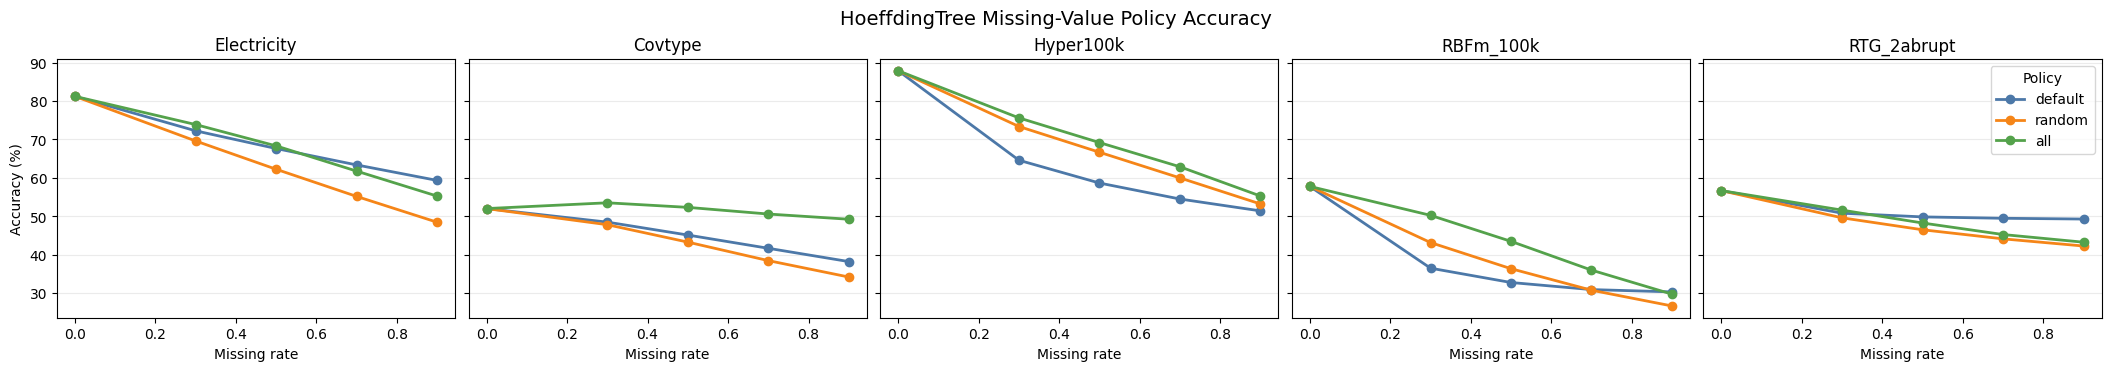

In [8]:
plot_metric_by_dataset(
    results=results,
    metric="accuracy",
    ylabel="Accuracy (%)",
    title="HoeffdingTree Missing-Value Policy Accuracy",
)
plt.show()

## Running Time Graph

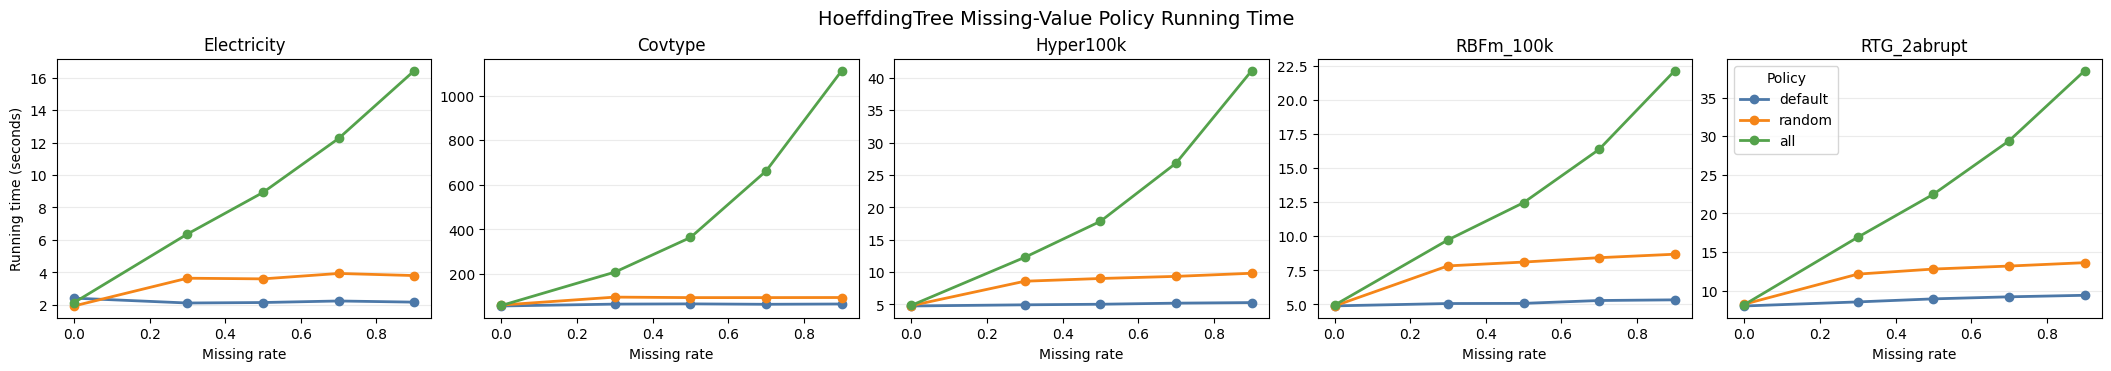

In [9]:
plot_metric_by_dataset(
    results=results,
    metric="seconds",
    ylabel="Running time (seconds)",
    title="HoeffdingTree Missing-Value Policy Running Time",
)
plt.show()

## Best Overall Policy Per Dataset


In [10]:
policy_summary = results.groupby(["dataset", "policy"], as_index=False).agg(
    mean_accuracy=("accuracy", "mean"),
    mean_seconds=("seconds", "mean"),
    total_seconds=("seconds", "sum"),
)

best_overall_policy = policy_summary.loc[
    policy_summary.groupby("dataset")["mean_accuracy"].idxmax()
].sort_values("dataset")

best_overall_policy.round(
    {
        "mean_accuracy": 2,
        "mean_seconds": 3,
        "total_seconds": 3,
    }
)

,dataset,policy,mean_accuracy,mean_seconds,total_seconds
0,Covtype,all,51.55,481.071,2405.354
4,Electricity,default,68.77,2.217,11.084
6,Hyper100k,all,70.18,20.586,102.932
9,RBFm_100k,all,43.47,13.126,65.630
13,RTG_2abrupt,default,51.24,8.816,44.078
